# create initial forcing using an existing file

In [1]:
import xarray as xr

In [2]:
import matplotlib.pyplot as plt

In [3]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 9.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39881,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42543,Total threads: 1
Dashboard: /proxy/40883/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:35813,


In [4]:
ic = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/kimberly_10k5_cropii_3/bathymetry.nc')
ic

<xarray.Dataset> Size: 82MB
Dimensions:    (ntiles: 1, ny: 1352, nx: 1677)
Dimensions without coordinates: ntiles, ny, nx
Data variables:
    y          (ntiles, ny, nx) float64 18MB ...
    x          (ntiles, ny, nx) float64 18MB ...
    mask       (ntiles, ny, nx) int32 9MB ...
    depth_raw  (ntiles, ny, nx) float64 18MB ...
    depth      (ntiles, ny, nx) float64 18MB ...
Attributes:
    date_created:  2026-06-30T23:43:00.364313
    title:         MOM6 topography file
    min_depth:     5
    max_depth:     7167.351864789052

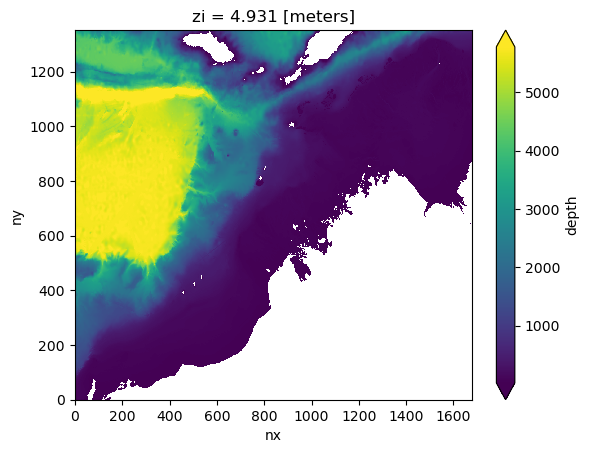

In [5]:
ic.depth.isel(ntiles=0).plot(robust=True)

In [13]:
ic = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/idealized/test03/INPUT/thickness_h.nc')
ic

<xarray.Dataset> Size: 1MB
Dimensions:  (zl: 1, xh: 1000, yh: 300)
Coordinates:
  * zl       (zl) float32 4B 1.0
  * xh       (xh) float32 4kB 500.0 1.5e+03 2.5e+03 ... 9.985e+05 9.995e+05
  * yh       (yh) float32 1kB 500.0 1.5e+03 2.5e+03 ... 2.985e+05 2.995e+05
Data variables:
    h        (yh, xh) float32 1MB ...

In [12]:
ic = xr.open_dataset('/home/130/ae7501/mom6_run_directories/idealized/test05/archive/output000/MOM_IC.nc')
eta = ic.eta
ic

/jobfs/156285413.gadi-pbs/ipykernel_2166700/1713308385.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ic = xr.open_dataset('/home/130/ae7501/mom6_run_directories/idealized/test05/archive/output000/MOM_IC.nc')


<xarray.Dataset> Size: 48MB
Dimensions:          (lath: 400, lonh: 1000, latq: 401, lonq: 1001, Layer: 1,
                      Interface: 2, Time: 1)
Coordinates:
  * lath             (lath) float64 3kB 500.0 1.5e+03 ... 3.985e+05 3.995e+05
  * lonh             (lonh) float64 8kB 500.0 1.5e+03 ... 9.985e+05 9.995e+05
  * latq             (latq) float64 3kB 0.0 1e+03 2e+03 ... 3.99e+05 4e+05
  * lonq             (lonq) float64 8kB 0.0 1e+03 2e+03 ... 9.99e+05 1e+06
  * Layer            (Layer) float64 8B 1.035e+03
  * Interface        (Interface) float64 16B 0.0 2.07e+03
  * Time             (Time) timedelta64[ns] 8B 00:00:00
Data variables: (12/16)
    h                (Time, Layer, lath, lonh) float64 3MB ...
    u                (Time, Layer, lath, lonq) float64 3MB ...
    v                (Time, Layer, latq, lonh) float64 3MB ...
    ave_ssh          (Time, lath, lonh) float64 3MB ...
    First_direction  (Time) float64 8B ...
    sfc              (Time, lath, lonh) float64 3MB ...
    ...               ...
    diffu            (Time, Layer, lath, lonq) float64 3MB ...
    diffv            (Time, Layer, latq, lonh) float64 3MB ...
    ubtav            (Time, lath, lonq) float64 3MB ...
    vbtav            (Time, latq, lonh) float64 3MB ...
    DTBT             (Time) timedelta64[ns] 8B ...
    eta              (Time, Interface, lath, lonh) float64 6MB ...
Attributes:
    filename:  ./MOM_IC.nc

In [19]:
ic.h

<xarray.DataArray 'h' (Time: 1, Layer: 1, lath: 400, lonh: 1000)> Size: 3MB
[400000 values with dtype=float64]
Coordinates:
  * lath     (lath) float64 3kB 500.0 1.5e+03 2.5e+03 ... 3.985e+05 3.995e+05
  * lonh     (lonh) float64 8kB 500.0 1.5e+03 2.5e+03 ... 9.985e+05 9.995e+05
  * Layer    (Layer) float64 8B 1.035e+03
  * Time     (Time) timedelta64[ns] 8B 00:00:00
Attributes:
    long_name:  Layer Thickness
    units:      m
    checksum:   AC20000000000000

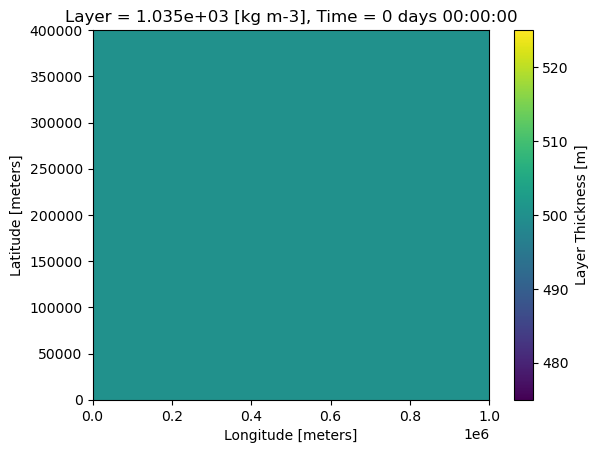

In [18]:
ic.h.isel(Time=0,Layer=0).plot(robust=True)

### combine glorys data 

In [4]:
ic = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/kimberly_10k5_cropii/forcing/init_eta.nc')
ic

<xarray.Dataset> Size: 9MB
Dimensions:  (xh: 1677, yh: 1352)
Coordinates:
  * xh       (xh) float64 13kB 114.8 114.8 114.8 114.8 ... 129.9 129.9 129.9
  * yh       (yh) float64 11kB -21.0 -20.99 -20.98 ... -9.272 -9.263 -9.254
Data variables:
    eta_t    (yh, xh) float32 9MB ...

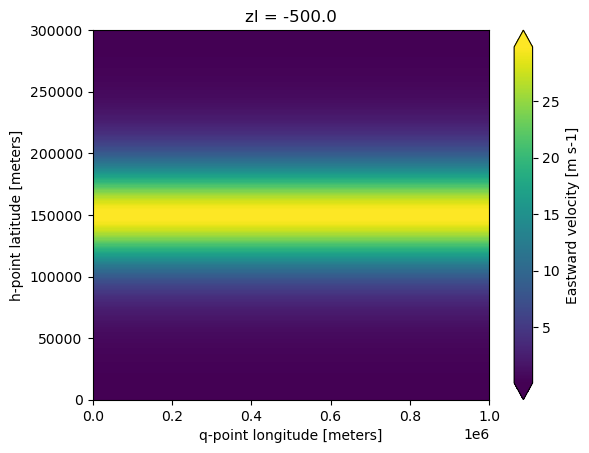

In [7]:
ic.u.plot(robust=True)

In [11]:
da = ic.isel(zl=0)   # get DataArray slice
plt.scatter(da[x], da[y])
plt.show()


NameError: name 'x' is not defined

In [25]:
ic = xr.open_dataset('/home/130/ae7501/mom6_run_directories/MOM6-examples/ocean_only/single_column/INPUT/Labrador/itides.nc')
ic

<xarray.Dataset> Size: 48B
Dimensions:    (gridlon_t: 2, gridlat_t: 2)
Coordinates:
  * gridlon_t  (gridlon_t) float32 8B 0.5 1.5
  * gridlat_t  (gridlat_t) float32 8B 0.5 1.5
Data variables:
    h2         (gridlat_t, gridlon_t) float32 16B ...
    tideamp    (gridlat_t, gridlon_t) float32 16B ...
Attributes:
    filename:  ICs.nc

In [14]:
ic = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly_10k5_cropii/inputdir/forcing/init_vel.nc')
ic

<xarray.Dataset> Size: 4GB
Dimensions:  (zl: 100, ny: 1352, nxp: 1678, nyp: 1353, nx: 1677)
Coordinates:
    xq       (ny, nxp) float64 18MB ...
    yh       (ny, nxp) float64 18MB ...
    xh       (nyp, nx) float64 18MB ...
    yq       (nyp, nx) float64 18MB ...
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Dimensions without coordinates: ny, nxp, nyp, nx
Data variables:
    u        (zl, ny, nxp) float64 2GB ...
    v        (zl, nyp, nx) float64 2GB ...
Attributes:
    regrid_method:  bilinear

In [ ]:
ic = xr.open_dataset('/g/data/nm03/ae7501/glorys_15_17/ic_unprocessed.nc')
ic

In [85]:
obc1 = xr.open_dataset('/g/data/nm03/ae7501/glorys_data/north_unprocessed.nc')
obc1

<xarray.Dataset> Size: 16GB
Dimensions:    (depth: 47, latitude: 13, longitude: 193, time: 4138)
Coordinates:
  * depth      (depth) float32 188B 0.494 1.541 2.646 ... 3.992e+03 4.405e+03
  * latitude   (latitude) float32 52B -9.5 -9.417 -9.333 ... -8.667 -8.583 -8.5
  * longitude  (longitude) float32 772B 114.5 114.6 114.7 ... 130.3 130.4 130.5
  * time       (time) datetime64[ns] 33kB 2015-01-01 2015-01-02 ... 2026-04-30
Data variables:
    bottomT    (time, latitude, longitude) float64 83MB ...
    mlotst     (time, latitude, longitude) float64 83MB ...
    so         (time, depth, latitude, longitude) float64 4GB ...
    thetao     (time, depth, latitude, longitude) float64 4GB ...
    uo         (time, depth, latitude, longitude) float64 4GB ...
    vo         (time, depth, latitude, longitude) float64 4GB ...
    zos        (time, latitude, longitude) float64 83MB ...
Attributes:
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    Conventions:               CF-1.4
    institution:               MERCATOR OCEAN
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    comment:                   CMEMS product
    references:                http://www.mercator-ocean.fr
    copernicusmarine_version:  2.2.1

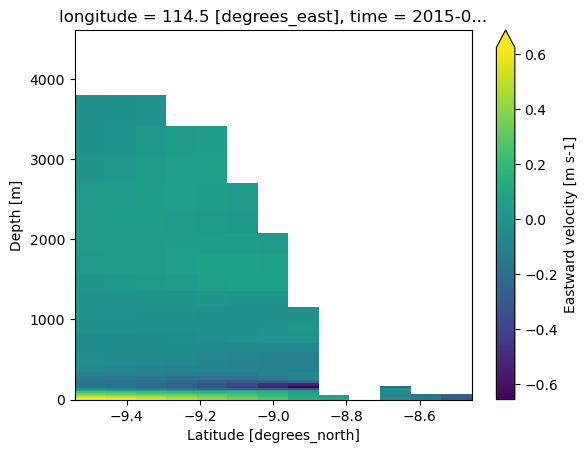

In [86]:
time = 10
vmin, vmax = obc1.uo.isel(time=time, longitude=0).quantile([0.0, 0.98])
obc1.uo.isel(time=time, longitude=0).plot(vmin=vmin, vmax=vmax)

In [92]:
import numpy as np

In [88]:
obc = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/kimberly_10k5_cropii_3/forcing_obc_segment_001.nc')
#obc.isel(time=-31).plot(robust=True)


In [97]:
arr = obc.v_segment_001.isel(time=time, ny_segment_001=0)

if np.all(np.isnan(arr)):
    print("yes, all are nans")
else:
    print("none")

none


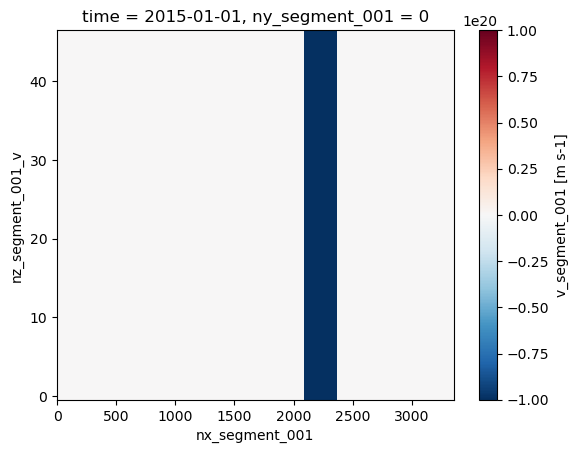

In [98]:
obc.v_segment_001.isel(time=time, ny_segment_001=0).plot(robust=True)

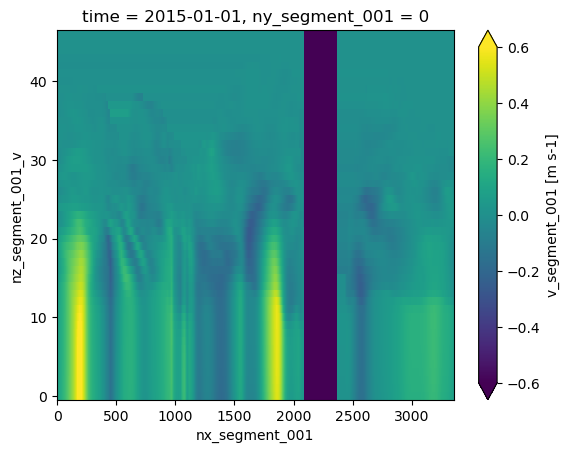

In [90]:
time = 0
vmin, vmax = obc.v_segment_001.isel(time=time, ny_segment_001=0).quantile([0.7, 0.98])
obc.v_segment_001.isel(time=time, ny_segment_001=0).plot(vmin=-0.6, vmax=0.6)

In [8]:
obc1 = xr.open_dataset('/g/data/nm03/ae7501/glorys_15_17/east_unprocessed3.nc')
obc1

<xarray.Dataset> Size: 289MB
Dimensions:    (time: 368, latitude: 147, longitude: 7, depth: 47)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2017-12-28 2017-12-29 ... 2018-12-30
  * latitude   (latitude) float32 588B -21.17 -21.08 -21.0 ... -9.083 -9.0
  * longitude  (longitude) float32 28B 129.7 129.8 129.8 129.9 130.0 130.1 130.2
  * depth      (depth) float32 188B 0.494 1.541 2.646 ... 3.992e+03 4.405e+03
Data variables:
    bottomT    (time, latitude, longitude) float32 2MB ...
    mlotst     (time, latitude, longitude) float32 2MB ...
    so         (time, depth, latitude, longitude) float32 71MB ...
    thetao     (time, depth, latitude, longitude) float32 71MB ...
    uo         (time, depth, latitude, longitude) float32 71MB ...
    vo         (time, depth, latitude, longitude) float32 71MB ...
    zos        (time, latitude, longitude) float32 2MB ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       MERCATOR OCEAN
    source:            MERCATOR GLORYS12V1
    history:           2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    references:        http://www.mercator-ocean.fr
    comment:           CMEMS product
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1D-m_202311
    subset:date:       2025-10-08T02:33:56.338Z

In [6]:
ERA = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/kimberly_10k5_cropii/forcing/trr_ERA5.nc')
ERA

<xarray.Dataset> Size: 404MB
Dimensions:    (latitude: 48, longitude: 60, time: 17520)
Coordinates:
  * latitude   (latitude) float32 192B -21.0 -20.75 -20.5 ... -9.75 -9.5 -9.25
  * longitude  (longitude) float32 240B 115.0 115.2 115.5 ... 129.2 129.5 129.8
  * time       (time) object 140kB 2017-12-28 00:00:00 ... 2019-12-27 23:00:00
Data variables:
    trr        (time, latitude, longitude) float64 404MB ...

In [23]:
# combine along time dimension
sdfsdfs
combined = xr.concat([obc1, obc2], dim="time")

# sort by time in case they overlap / are out of order
combined = combined.sortby("time")

# (optional) save to new NetCDF
combined.to_netcdf('/g/data/nm03/ae7501/glorys_15_17/north_unprocessed.nc')

### forcing fields--- random check

In [57]:
obc = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/kimberly_10k5_cropii_3/forcing_obc_segment_003.nc')
#obc.isel(time=-31).plot(robust=True)
obc

<xarray.Dataset> Size: 34GB
Dimensions:              (time: 4138, nz_segment_003_u: 47,
                          ny_segment_003: 2705, nx_segment_003: 1,
                          nz_segment_003_v: 47, nz_segment_003_salt: 47,
                          nz_segment_003_temp: 47, nz_salt_segment_003: 47,
                          nz_temp_segment_003: 47, nz_u_segment_003: 47,
                          nz_v_segment_003: 47, depth: 47)
Coordinates:
  * depth                (depth) float32 188B 0.494 1.541 ... 4.405e+03
  * time                 (time) datetime64[ns] 33kB 2015-01-01 ... 2026-04-30
    lon_segment_003      (ny_segment_003) float64 22kB ...
    lat_segment_003      (ny_segment_003) float64 22kB ...
  * nz_segment_003_salt  (nz_segment_003_salt) int32 188B 0 1 2 3 ... 44 45 46
  * nz_segment_003_temp  (nz_segment_003_temp) int32 188B 0 1 2 3 ... 44 45 46
  * nz_segment_003_u     (nz_segment_003_u) int32 188B 0 1 2 3 4 ... 43 44 45 46
  * nz_segment_003_v     (nz_segment_003_v) int32 188B 0 1 2 3 4 ... 43 44 45 46
  * nx_segment_003       (nx_segment_003) int32 4B 0
  * ny_segment_003       (ny_segment_003) int32 11kB 0 1 2 3 ... 2702 2703 2704
Dimensions without coordinates: nz_salt_segment_003, nz_temp_segment_003,
                                nz_u_segment_003, nz_v_segment_003
Data variables:
    u_segment_003        (time, nz_segment_003_u, ny_segment_003, nx_segment_003) float64 4GB ...
    v_segment_003        (time, nz_segment_003_v, ny_segment_003, nx_segment_003) float64 4GB ...
    eta_segment_003      (time, ny_segment_003, nx_segment_003) float64 90MB ...
    salt_segment_003     (time, nz_segment_003_salt, ny_segment_003, nx_segment_003) float64 4GB ...
    temp_segment_003     (time, nz_segment_003_temp, ny_segment_003, nx_segment_003) float64 4GB ...
    dz_salt_segment_003  (time, nz_salt_segment_003, ny_segment_003, nx_segment_003) float64 4GB ...
    dz_temp_segment_003  (time, nz_temp_segment_003, ny_segment_003, nx_segment_003) float64 4GB ...
    dz_u_segment_003     (time, nz_u_segment_003, ny_segment_003, nx_segment_003) float64 4GB ...
    dz_v_segment_003     (time, nz_v_segment_003, ny_segment_003, nx_segment_003) float64 4GB ...
Attributes:
    regrid_method:  bilinear

In [58]:
obc.u_segment_003.nx_segment_003.values

array([0], dtype=int32)

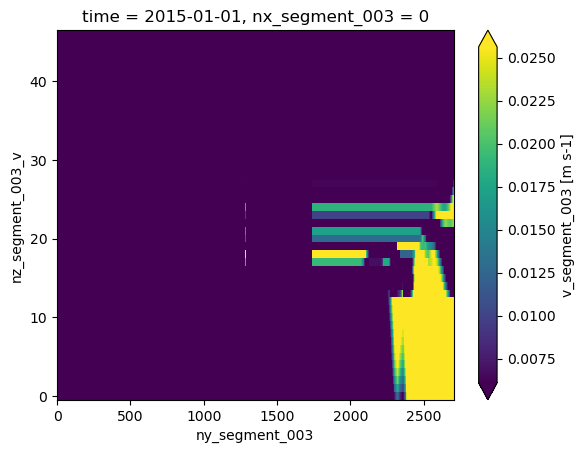

In [59]:
time = 0
vmin, vmax = obc.v_segment_003.isel(time=time, nx_segment_003=0).quantile([0.90, 0.95])
obc.v_segment_003.isel(time=time, nx_segment_003=0).plot(vmin=vmin, vmax=vmax)

In [52]:
obc.u_segment_003.isel(time=110,nx_segment_003=0).plot(robust=True)

AttributeError: 'Dataset' object has no attribute 'u_segment_003'

In [32]:
obc.u_segment_003.isel(time=1,ny_segment_003=0).values

array([[-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20],
       [-1.e+20]])

In [9]:
obc = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly_10k5_cropii/inputdir/forcing/new_obc/forcing_obc_segment_001.nc')
obc

<xarray.Dataset> Size: 931MB
Dimensions:              (depth: 47, time: 184, nz_segment_001_u: 47,
                          ny_segment_001: 1, nx_segment_001: 3355,
                          nz_segment_001_v: 47, nz_segment_001_salt: 47,
                          nz_segment_001_temp: 47, nz_salt_segment_001: 47,
                          nz_temp_segment_001: 47, nz_u_segment_001: 47,
                          nz_v_segment_001: 47)
Coordinates:
  * depth                (depth) float32 188B 0.494 1.541 ... 4.405e+03
  * time                 (time) object 1kB 2016-12-02 00:00:00 ... 2017-06-03...
  * nz_segment_001_salt  (nz_segment_001_salt) int32 188B 0 1 2 3 ... 44 45 46
  * nz_segment_001_temp  (nz_segment_001_temp) int32 188B 0 1 2 3 ... 44 45 46
  * nz_segment_001_u     (nz_segment_001_u) int32 188B 0 1 2 3 4 ... 43 44 45 46
  * nz_segment_001_v     (nz_segment_001_v) int32 188B 0 1 2 3 4 ... 43 44 45 46
  * nx_segment_001       (nx_segment_001) int32 13kB 0 1 2 3 ... 3352 3353 3354
  * ny_segment_001       (ny_segment_001) int32 4B 0
Dimensions without coordinates: nz_salt_segment_001, nz_temp_segment_001,
                                nz_u_segment_001, nz_v_segment_001
Data variables:
    u_segment_001        (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float32 116MB ...
    v_segment_001        (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float32 116MB ...
    eta_segment_001      (time, ny_segment_001, nx_segment_001) float32 2MB ...
    salt_segment_001     (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float32 116MB ...
    temp_segment_001     (time, nz_segment_001_temp, ny_segment_001, nx_segment_001) float32 116MB ...
    dz_salt_segment_001  (time, nz_salt_segment_001, ny_segment_001, nx_segment_001) float32 116MB ...
    dz_temp_segment_001  (time, nz_temp_segment_001, ny_segment_001, nx_segment_001) float32 116MB ...
    dz_u_segment_001     (time, nz_u_segment_001, ny_segment_001, nx_segment_001) float32 116MB ...
    dz_v_segment_001     (time, nz_v_segment_001, ny_segment_001, nx_segment_001) float32 116MB ...
    lon_segment_001      (ny_segment_001, nx_segment_001) float64 27kB ...
    lat_segment_001      (ny_segment_001, nx_segment_001) float64 27kB ...
Attributes:
    regrid_method:  bilinear

In [12]:
obc = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly_10k5_cropii/inputdir/forcing/init_eta.nc')
obc

<xarray.Dataset> Size: 9MB
Dimensions:  (xh: 1677, yh: 1352)
Coordinates:
  * xh       (xh) float64 13kB 114.8 114.8 114.8 114.8 ... 129.9 129.9 129.9
  * yh       (yh) float64 11kB -21.0 -20.99 -20.98 ... -9.272 -9.263 -9.254
Data variables:
    eta_t    (yh, xh) float32 9MB ...

In [ ]:
obc = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis25/inputdir/forcing/init_eta.nc')
obc

In [ ]:
obc = xr.open_dataset('/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/east_unprocessed.nc')
obc

In [20]:
ds2 = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly_10k5_cropii9/inputdir/rundir/inputdir/forcing/10u_ERA5.nc')
ds2

<xarray.Dataset> Size: 404MB
Dimensions:    (latitude: 48, time: 17520, longitude: 60)
Coordinates:
  * latitude   (latitude) float32 192B -21.0 -20.75 -20.5 ... -9.75 -9.5 -9.25
  * longitude  (longitude) float32 240B 115.0 115.2 115.5 ... 129.2 129.5 129.8
  * time       (time) object 140kB 2018-12-27 00:00:00 ... 2020-12-25 23:00:00
Data variables:
    u10        (time, latitude, longitude) float64 404MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-26 23:33:21 UTC+1000 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis 10m_u_component_of_wind 20180...

In [ ]:
ds = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis21/inputdir/rundir/inputdir/forcing/10u_ERA5.nc')

In [ ]:
ds

In [ ]:
time_index = 0  # First time step
depth_index =0  # First depth level

In [ ]:
v_segment_001 = ds.variables['v_segment_001'].isel(time=time_index, ny_segment_001=depth_index)

In [ ]:
v_segment_001

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
v_segment_001.plot()
plt.title('v_segment_001 at time index {} and depth index {}'.format(time_index, depth_index))
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.show()

### looking into initial condition files----- Random

In [7]:
ds = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis20/archive/output022/20230202.ocean_dailyhalf.nc')

In [8]:
ds

<xarray.Dataset> Size: 383GB
Dimensions:                            (xh: 2611, yh: 1285, time: 56, nv: 2,
                                        xq: 2612, yq: 1286, zl: 100)
Coordinates:
  * xh                                 (xh) float64 21kB 96.01 96.03 ... 143.0
  * yh                                 (yh) float64 10kB -28.99 ... -7.009
  * time                               (time) object 448B 2023-02-02 06:00:00...
  * nv                                 (nv) float64 16B 1.0 2.0
  * xq                                 (xq) float64 21kB 96.0 96.02 ... 143.0
  * yq                                 (yq) float64 10kB -29.0 -28.98 ... -7.0
  * zl                                 (zl) float64 800B 2.465 ... 5.452e+03
Data variables: (12/19)
    zos                                (time, yh, xh) float32 752MB ...
    tos                                (time, yh, xh) float32 752MB ...
    sos                                (time, yh, xh) float32 752MB ...
    tob                                (time, yh, xh) float32 752MB ...
    sob                                (time, yh, xh) float32 752MB ...
    mlotst                             (time, yh, xh) float32 752MB ...
    ...                                 ...
    rhoinsitu                          (time, zl, yh, xh) float32 75GB ...
    temp                               (time, zl, yh, xh) float32 75GB ...
    average_T1                         (time) datetime64[ns] 448B ...
    average_T2                         (time) datetime64[ns] 448B ...
    average_DT                         (time) timedelta64[ns] 448B ...
    time_bnds                          (time, nv) object 896B ...
Attributes:
    NumFilesInSet:     1
    title:             mom6-regional
    associated_files:  areacello: 20230202.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [9]:
ds1= ds.drop_vars(['taux', 'tauy', 'speed', 'boundary_forcing_heat_tendency_2d','average_DT','average_T2', 'average_T1','tos', 'sos','sob', 'rhoinsitu','time_bnds','nv'])

In [10]:
ds1

<xarray.Dataset> Size: 303GB
Dimensions:  (xh: 2611, yh: 1285, time: 56, xq: 2612, yq: 1286, zl: 100)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
  * time     (time) object 448B 2023-02-02 06:00:00 ... 2023-03-01 18:00:00
  * xq       (xq) float64 21kB 96.0 96.02 96.04 96.05 ... 143.0 143.0 143.0
  * yq       (yq) float64 10kB -29.0 -28.98 -28.97 -28.95 ... -7.034 -7.017 -7.0
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 5.452e+03
Data variables:
    zos      (time, yh, xh) float32 752MB ...
    tob      (time, yh, xh) float32 752MB ...
    mlotst   (time, yh, xh) float32 752MB ...
    u        (time, zl, yh, xq) float32 75GB ...
    v        (time, zl, yq, xh) float32 75GB ...
    salt     (time, zl, yh, xh) float32 75GB ...
    temp     (time, zl, yh, xh) float32 75GB ...
Attributes:
    NumFilesInSet:     1
    title:             mom6-regional
    associated_files:  areacello: 20230202.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [11]:
ds2 =ds1.isel(time=0)

In [12]:
ds2

<xarray.Dataset> Size: 5GB
Dimensions:  (xh: 2611, yh: 1285, xq: 2612, yq: 1286, zl: 100)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
    time     object 8B 2023-02-02 06:00:00
  * xq       (xq) float64 21kB 96.0 96.02 96.04 96.05 ... 143.0 143.0 143.0
  * yq       (yq) float64 10kB -29.0 -28.98 -28.97 -28.95 ... -7.034 -7.017 -7.0
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 5.452e+03
Data variables:
    zos      (yh, xh) float32 13MB ...
    tob      (yh, xh) float32 13MB ...
    mlotst   (yh, xh) float32 13MB ...
    u        (zl, yh, xq) float32 1GB ...
    v        (zl, yq, xh) float32 1GB ...
    salt     (zl, yh, xh) float32 1GB ...
    temp     (zl, yh, xh) float32 1GB ...
Attributes:
    NumFilesInSet:     1
    title:             mom6-regional
    associated_files:  areacello: 20230202.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [13]:
ds_renamed = ds2.rename({"salt": "so", "u": "uo", "v":"vo","tob":"bottomT","temp":"thetao"})
ds_renamed

<xarray.Dataset> Size: 5GB
Dimensions:  (xh: 2611, yh: 1285, xq: 2612, yq: 1286, zl: 100)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
    time     object 8B 2023-02-02 06:00:00
  * xq       (xq) float64 21kB 96.0 96.02 96.04 96.05 ... 143.0 143.0 143.0
  * yq       (yq) float64 10kB -29.0 -28.98 -28.97 -28.95 ... -7.034 -7.017 -7.0
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 5.452e+03
Data variables:
    zos      (yh, xh) float32 13MB ...
    bottomT  (yh, xh) float32 13MB ...
    mlotst   (yh, xh) float32 13MB ...
    uo       (zl, yh, xq) float32 1GB ...
    vo       (zl, yq, xh) float32 1GB ...
    so       (zl, yh, xh) float32 1GB ...
    thetao   (zl, yh, xh) float32 1GB ...
Attributes:
    NumFilesInSet:     1
    title:             mom6-regional
    associated_files:  areacello: 20230202.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

In [14]:
ds_renamed.to_netcdf("/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/ic_from_mom6_output.nc") # this file dosent have the lon lat coord to be used with regional mom6

In [15]:
ic_from_original = xr.open_dataset('/g/data/nm03/ae7501/k17_data/GLORYS_DATA_1/ic_unprocessed.nc')
ic_from_original

<xarray.Dataset> Size: 234MB
Dimensions:    (depth: 48, latitude: 265, longitude: 565, time: 1)
Coordinates:
  * depth      (depth) float32 192B 0.494 1.541 2.646 ... 4.405e+03 4.833e+03
  * latitude   (latitude) float32 1kB -29.0 -28.92 -28.83 ... -7.167 -7.083 -7.0
  * longitude  (longitude) float32 2kB 96.0 96.08 96.17 ... 142.8 142.9 143.0
  * time       (time) datetime64[ns] 8B 2021-11-01
Data variables:
    bottomT    (time, latitude, longitude) float64 1MB ...
    mlotst     (time, latitude, longitude) float64 1MB ...
    thetao     (time, depth, latitude, longitude) float64 57MB ...
    uo         (time, depth, latitude, longitude) float64 57MB ...
    vo         (time, depth, latitude, longitude) float64 57MB ...
    zos        (time, latitude, longitude) float64 1MB ...
    so         (time, depth, latitude, longitude) float64 57MB ...
Attributes:
    copernicusmarine_version:  1.3.1

### Create the three initial forcing files using an existing file and model output------ IMPORTANT

In [5]:
initial_forc_ori = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis25/inputdir/forcing/init_vel.nc')
initial_forc_ori

<xarray.Dataset> Size: 3GB
Dimensions:  (zl: 100, ny: 1285, nxp: 2612, nyp: 1286, nx: 2611)
Coordinates:
    xq       (ny, nxp) float64 27MB ...
    yh       (ny, nxp) float64 27MB ...
    xh       (nyp, nx) float64 27MB ...
    yq       (nyp, nx) float64 27MB ...
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Dimensions without coordinates: ny, nxp, nyp, nx
Data variables:
    u        (zl, ny, nxp) float32 1GB ...
    v        (zl, nyp, nx) float32 1GB ...
Attributes:
    regrid_method:  bilinear

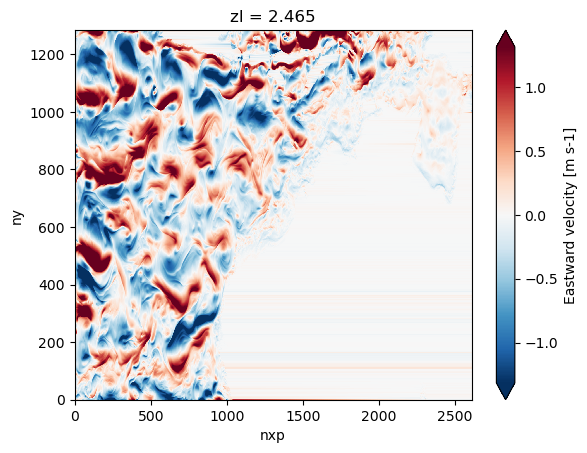

In [6]:
initial_forc_ori.u.isel(zl=0).plot(robust=True)

In [7]:
# output from the model run that is used to create the innitial conditions
model_out = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis20/archive/output022/20230202.ocean_dailyhalf.nc')
#model_out = xr.open_dataset('/scratch/nm03/ae7501/mom6/archive/kimberly-reanalysis24/output002/20230303.ocean_dailyhalf.nc')
model_out

<xarray.Dataset> Size: 383GB
Dimensions:                            (xh: 2611, yh: 1285, time: 56, nv: 2,
                                        xq: 2612, yq: 1286, zl: 100)
Coordinates:
  * xh                                 (xh) float64 21kB 96.01 96.03 ... 143.0
  * yh                                 (yh) float64 10kB -28.99 ... -7.009
  * time                               (time) object 448B 2023-02-02 06:00:00...
  * nv                                 (nv) float64 16B 1.0 2.0
  * xq                                 (xq) float64 21kB 96.0 96.02 ... 143.0
  * yq                                 (yq) float64 10kB -29.0 -28.98 ... -7.0
  * zl                                 (zl) float64 800B 2.465 ... 5.452e+03
Data variables: (12/19)
    zos                                (time, yh, xh) float32 752MB ...
    tos                                (time, yh, xh) float32 752MB ...
    sos                                (time, yh, xh) float32 752MB ...
    tob                                (time, yh, xh) float32 752MB ...
    sob                                (time, yh, xh) float32 752MB ...
    mlotst                             (time, yh, xh) float32 752MB ...
    ...                                 ...
    rhoinsitu                          (time, zl, yh, xh) float32 75GB ...
    temp                               (time, zl, yh, xh) float32 75GB ...
    average_T1                         (time) datetime64[ns] 448B ...
    average_T2                         (time) datetime64[ns] 448B ...
    average_DT                         (time) timedelta64[ns] 448B ...
    time_bnds                          (time, nv) object 896B ...
Attributes:
    NumFilesInSet:     1
    title:             mom6-regional
    associated_files:  areacello: 20230202.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

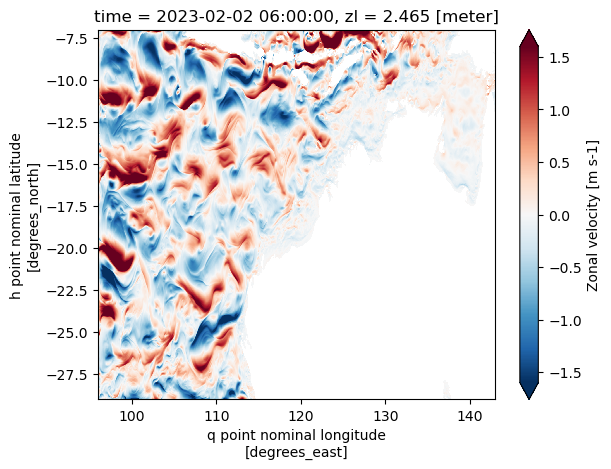

In [8]:
model_out.u.isel(time=0,zl=0).plot(robust=True)

In [9]:
initial_forc_ori.u.values = model_out.u.isel(time=0).values
initial_forc_ori.v.values = model_out.v.isel(time = 0).values
initial_forc_ori

<xarray.Dataset> Size: 3GB
Dimensions:  (zl: 100, ny: 1285, nxp: 2612, nyp: 1286, nx: 2611)
Coordinates:
    xq       (ny, nxp) float64 27MB ...
    yh       (ny, nxp) float64 27MB ...
    xh       (nyp, nx) float64 27MB ...
    yq       (nyp, nx) float64 27MB ...
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Dimensions without coordinates: ny, nxp, nyp, nx
Data variables:
    u        (zl, ny, nxp) float32 1GB -0.4433 -0.4818 -0.4821 ... nan nan nan
    v        (zl, nyp, nx) float32 1GB -0.125 -0.1732 -0.2151 ... nan nan nan
Attributes:
    regrid_method:  bilinear

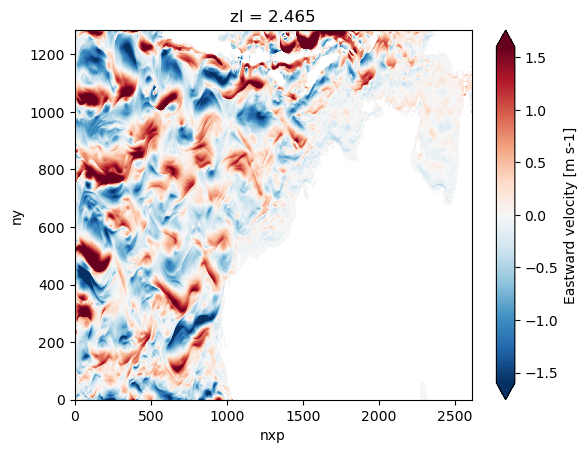

In [10]:
initial_forc_ori.u.isel(zl=0).plot(robust=True)

In [11]:
#remove the nans by interpolating data. this block is copied from regional mom6
initial_forc_ori["v"] = (
    initial_forc_ori["v"].interpolate_na("nx", method="linear")
    .ffill("nx").bfill("nx")
    .ffill("nyp").bfill("nyp")
    .ffill("zl").bfill("zl")
)
initial_forc_ori["u"] = (
    initial_forc_ori["u"].interpolate_na("nxp", method="linear")
    .ffill("nxp").bfill("nxp")
    .ffill("ny").bfill("ny")
    .ffill("zl").bfill("zl")
)

In [12]:
initial_forc_ori

<xarray.Dataset> Size: 3GB
Dimensions:  (zl: 100, ny: 1285, nxp: 2612, nyp: 1286, nx: 2611)
Coordinates:
    xq       (ny, nxp) float64 27MB ...
    yh       (ny, nxp) float64 27MB ...
    xh       (nyp, nx) float64 27MB ...
    yq       (nyp, nx) float64 27MB ...
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Dimensions without coordinates: ny, nxp, nyp, nx
Data variables:
    u        (zl, ny, nxp) float32 1GB -0.4433 -0.4818 ... 2.702e-06 2.702e-06
    v        (zl, nyp, nx) float32 1GB -0.125 -0.1732 ... 5.282e-05 5.282e-05
Attributes:
    regrid_method:  bilinear

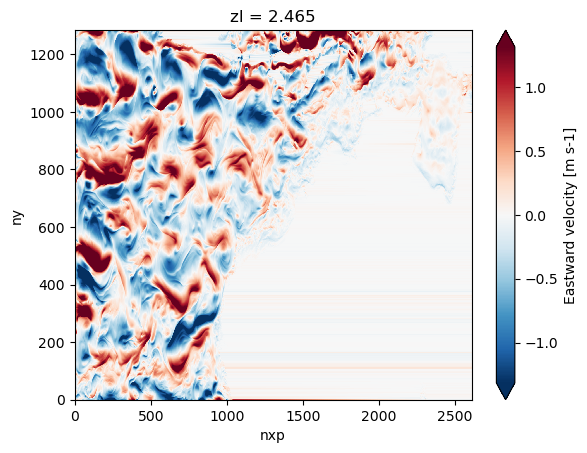

In [13]:
initial_forc_ori.u.isel(zl=0).plot(robust=True)

In [14]:
nan_count = initial_forc_ori.v.isnull().sum()
print(f"Number of NaN values: {nan_count}")

Number of NaN values: <xarray.DataArray 'v' ()> Size: 8B
array(0)


#### repeat for other init conditions

In [15]:
initial_trac_ori = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis25/inputdir/forcing/init_tracers.nc')
initial_eta_ori = xr.open_dataset('/home/130/ae7501/mom6_run_directories/kimberly-reanalysis25/inputdir/forcing/init_eta.nc')

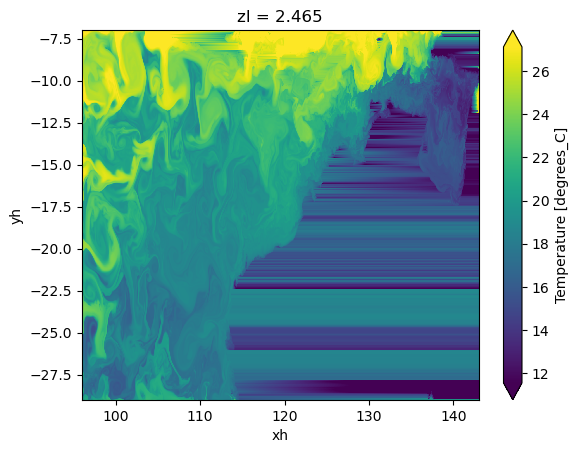

In [16]:
initial_trac_ori.temp.isel(zl=0).plot(robust=True)

In [17]:
initial_trac_ori

<xarray.Dataset> Size: 3GB
Dimensions:  (xh: 2611, yh: 1285, zl: 100)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Data variables:
    salt     (zl, yh, xh) float32 1GB ...
    temp     (zl, yh, xh) float32 1GB ...
Attributes:
    regrid_method:  bilinear

In [18]:
initial_eta_ori

<xarray.Dataset> Size: 13MB
Dimensions:  (xh: 2611, yh: 1285)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
Data variables:
    eta_t    (yh, xh) float32 13MB ...

In [19]:
initial_trac_ori.salt.values = model_out.salt.isel(time=0).values
initial_trac_ori.temp.values = model_out.temp.isel(time = 0).values

In [20]:
initial_eta_ori.eta_t.values = model_out.zos.isel(time = 0).values

In [21]:
initial_trac_ori["salt"] = (
    initial_trac_ori["salt"].interpolate_na("xh", method="linear")
    .ffill("xh").bfill("xh")
    .ffill("yh").bfill("yh")
    .ffill("zl").bfill("zl")
)

initial_trac_ori["temp"] = (
    initial_trac_ori["temp"].interpolate_na("xh", method="linear")
    .ffill("xh").bfill("xh")
    .ffill("yh").bfill("yh")
    .ffill("zl").bfill("zl")
)

initial_eta_ori["eta_t"] = (
    initial_eta_ori["eta_t"].interpolate_na("xh", method="linear")
    .ffill("xh").bfill("xh")
    .ffill("yh").bfill("yh")
)

In [22]:
initial_trac_ori

<xarray.Dataset> Size: 3GB
Dimensions:  (xh: 2611, yh: 1285, zl: 100)
Coordinates:
  * xh       (xh) float64 21kB 96.01 96.03 96.05 96.06 ... 143.0 143.0 143.0
  * yh       (yh) float64 10kB -28.99 -28.97 -28.96 ... -7.043 -7.026 -7.009
  * zl       (zl) float64 800B 2.465 7.407 12.37 ... 4.857e+03 4.952e+03
Data variables:
    salt     (zl, yh, xh) float32 1GB 35.75 35.75 35.75 ... 27.05 27.05 27.05
    temp     (zl, yh, xh) float32 1GB 20.18 20.19 20.21 ... 25.65 25.65 25.65
Attributes:
    regrid_method:  bilinear

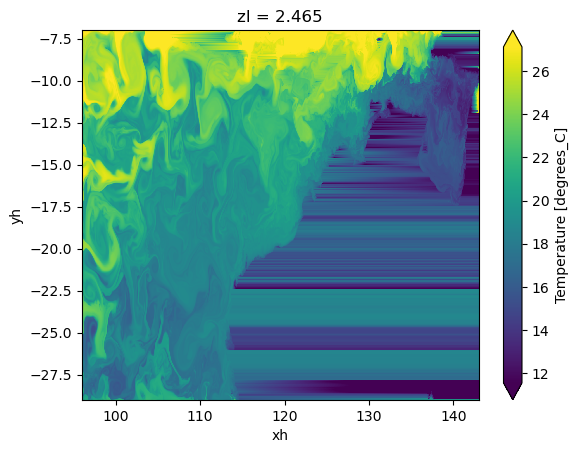

In [23]:
initial_trac_ori.temp.isel(zl=0).plot(robust=True)

In [24]:
nan_count = initial_trac_ori.temp.isnull().sum()
print(f"Number of NaN values: {nan_count}")

Number of NaN values: <xarray.DataArray 'temp' ()> Size: 8B
array(0)


In [25]:
import netCDF4

In [26]:
initial_forc_ori.to_netcdf(
    '/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis25/forcing/init_vel1.nc',
    mode="w",
    encoding={
        "u": {"_FillValue": netCDF4.default_fillvals["f4"]},
        "v": {"_FillValue": netCDF4.default_fillvals["f4"]},
    },
)

initial_trac_ori.to_netcdf(
    '/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis25/forcing/init_tracers1.nc',
    mode="w",
    encoding={
        "xh": {"_FillValue": None},
        "yh": {"_FillValue": None},
        "zl": {"_FillValue": None},
        "temp": {"_FillValue": -1e20, "missing_value": -1e20},
        "salt": {"_FillValue": -1e20, "missing_value": -1e20},
    },
)

initial_eta_ori.to_netcdf(
    '/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis25/forcing/init_eta1.nc',
    mode="w",
    encoding={
        "xh": {"_FillValue": None},
        "yh": {"_FillValue": None},
        "eta_t": {"_FillValue": None},
    },
)
# this saving method got the ic files to work properly. fillvalues has something to do?

In [27]:
#initial_forc_ori.to_netcdf('/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis24/forcing/init_vel.nc') #saving like this gave me errors with temperature field
#initial_trac_ori.to_netcdf('/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis24/forcing/init_tracers.nc')
#initial_eta_ori.to_netcdf('/scratch/nm03/ae7501/mom6_input_directories/kimberly-reanalysis24/forcing/init_eta.nc')

### slice the dates for boundaries ---- used once for a short experiment

In [15]:
obc1 = xr.open_dataset('/g/data/nm03/ae7501/k17_data/GLORYS_DATA_1/east_unprocessed.nc')
obc2 = xr.open_dataset('/g/data/nm03/ae7501/k17_data/GLORYS_DATA_1/south_unprocessed.nc')
obc3= xr.open_dataset('/g/data/nm03/ae7501/k17_data/GLORYS_DATA_1/west_unprocessed.nc')
obc4 = xr.open_dataset('/g/data/nm03/ae7501/k17_data/GLORYS_DATA_1/north_unprocessed.nc')

In [16]:
obc1 = obc1.sel(time=slice( '2023-02-02 00:00:00', '2024-04-17 00:00:00'))
obc2 = obc2.sel(time=slice( '2023-02-02 00:00:00', '2024-04-17 00:00:00'))
obc3 = obc3.sel(time=slice( '2023-02-02 00:00:00', '2024-04-17 00:00:00'))
obc4 = obc4.sel(time=slice( '2023-02-02 00:00:00', '2024-04-17 00:00:00'))

In [17]:
obc1

<xarray.Dataset> Size: 2GB
Dimensions:    (depth: 48, latitude: 277, longitude: 13, time: 441)
Coordinates:
  * depth      (depth) float32 192B 0.494 1.541 2.646 ... 4.405e+03 4.833e+03
  * latitude   (latitude) float32 1kB -29.5 -29.42 -29.33 ... -6.667 -6.583 -6.5
  * longitude  (longitude) float32 52B 142.5 142.6 142.7 ... 143.3 143.4 143.5
  * time       (time) datetime64[ns] 4kB 2023-02-02 2023-02-03 ... 2024-04-17
Data variables:
    bottomT    (time, latitude, longitude) float64 13MB ...
    mlotst     (time, latitude, longitude) float64 13MB ...
    thetao     (time, depth, latitude, longitude) float64 610MB ...
    uo         (time, depth, latitude, longitude) float64 610MB ...
    vo         (time, depth, latitude, longitude) float64 610MB ...
    zos        (time, latitude, longitude) float64 13MB ...
    so         (time, depth, latitude, longitude) float64 610MB ...
Attributes:
    copernicusmarine_version:  1.3.1

In [18]:
obc1.to_netcdf('/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/east_unprocessed.nc')
obc2.to_netcdf('/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/south_unprocessed.nc')
obc3.to_netcdf('/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/west_unprocessed.nc')
obc4.to_netcdf('/g/data/nm03/ae7501/k22_data/GLORYS_DATA_2/north_unprocessed.nc')